<a href="https://colab.research.google.com/github/thedatasense/llm-healthcare/blob/main/MIMIC_GPT_Evaluation_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install -q  sqlalchemy  pandas psycopg2-binary matplotlib

In [2]:
# Standard Library Imports
import base64
import io
import json
import os
import platform
import random
import sys
import time
import traceback

# Third-Party Imports
from IPython.display import display, clear_output
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from openai import OpenAI
import pandas as pd
from PIL import Image
import requests
from sqlalchemy import create_engine, text # Consolidated from sqlalchemy.engine and sqlalchemy
import torch
import yaml

In [4]:
cnfig_file="/Users/bineshkumar/Documents/config.yaml"
def get_from_cnfg(key_path,file_path=cnfig_file):
    try:
        with open(file_path, 'r') as file:
            data = yaml.safe_load(file)

        keys = key_path.split('.')
        value = data
        for key in keys:
            value = value[key]
        return value

    except FileNotFoundError:
        print(f"File {file_path} not found")
    except yaml.YAMLError as e:
        print(f"YAML parsing error: {e}")
    except KeyError:
        print(f"Key path {key_path} not found")
    except Exception as e:
        print(f"Error: {e}")
    return None
os_name = platform.system()

In [5]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    from google.colab import userdata
    engine = create_engine(userdata.get('DB_URL'))
    gem_key=userdata.get('DB_URL')
    oai_key=userdata.get('DB_URL')
    source_folder='/content/drive/MyDrive/Health_Data/MIMIC_JPG_AVL/mimic-cxr-jpg/2.1.0/files/'
elif os_name == "Darwin":
    cnfig_file="/Users/bineshkumar/Documents/config.yaml"
    DB_URL = get_from_cnfg("gcp_db_url",cnfig_file)
    gem_key=get_from_cnfg("gem_token",cnfig_file)
    oai_key=get_from_cnfg("oai_token",cnfig_file)
    source_folder='/Users/bineshkumar/Documents/mimic-cxr-jpg/2.1.0/files/'
elif os_name == "Linux":
    DB_URL = get_from_cnfg("gcp_db_url",cnfig_file)
    gem_key=get_from_cnfg("gem_token",cnfig_file)
    oai_key=get_from_cnfg("oai_token",cnfig_file)
    source_folder=""
engine = create_engine(DB_URL)

In [6]:
def check_duplicate(full_file_path):
    try:
        with engine.connect() as conn:
            result = conn.execute(text(
                "SELECT COUNT(*) FROM mimicxp.svu_all_qns WHERE full_file_path = :path"
            ), {"path": full_file_path})
            count = result.scalar()
            return count > 0
    except Exception as e:
        error_message = f"Error checking if image is processed: {str(e)}"
        print(error_message)
        error_logs.append({
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
            "file_path": full_file_path,
            "error_type": "DB_QUERY_ERROR",
            "error_message": error_message,
            "traceback": traceback.format_exc()
        })
        save_error_logs_safe()
        return False

In [7]:
def fetch_generation_data(engine):
    import pandas as pd
    import re
    from sqlalchemy import text
    from sqlalchemy.dialects.postgresql.base import PGDialect
    def fake_get_server_version_info(self, connection):
        version_str = connection.execute(text("SELECT version()")).scalar()
        match = re.search(r'v(\d+)\.(\d+)\.(\d+)', version_str)
        if match:
            return tuple(map(int, match.groups()))
        return (13, 0, 0)
    PGDialect._get_server_version_info = fake_get_server_version_info
    query = text("""select id,
       case_id,
       frame_file,
       full_file_path,
       ground_truth,
       gpt_response,
       original_response
    from svu_all_qns a left join model_responses_r2 b
    on b.question_id=a.case_id || '_' || a.id and
    b.model_name = :model_id and b.question_id is null
;;
    """)
    # Execute with model_id parameter
    model_id = "gpt-4o"  # Update this as needed
    return pd.read_sql(query, con=engine, params={"model_id": model_id})

In [9]:
fetch_generation_data(engine)

,id,case_id,frame_file,full_file_path,ground_truth,gpt_response,original_response
0,3,1,row0_monopolar_curved_scissors.png,/Volumes/TVault2/datasets/sugvu24/extracted_fr...,monopolar curved scissors,Cadiere Forceps,"```json\n{\n ""instruments"": [\n ""Cadiere F..."
1,4,1,row1_bipolar_forceps.png,/Volumes/TVault2/datasets/sugvu24/extracted_fr...,bipolar forceps,"Monopolar Curved Scissors, Cadiere Forceps","{\n ""instruments"": [\n ""Monopolar Curved S..."
2,5,1,row2_bipolar_forceps.png,/Volumes/TVault2/datasets/sugvu24/extracted_fr...,bipolar forceps,"Monopolar Curved Scissors, Cardiere Forceps","{\n ""instruments"": [\n ""Monopolar Curved S..."
3,6,1,row3_grasping_retractor.png,/Volumes/TVault2/datasets/sugvu24/extracted_fr...,grasping retractor,"Monopolar Curved Scissors, Maryland Bipolar Fo...","{\n ""instruments"": [\n ""Monopolar Curved S..."
4,7,1,row4_grasping_retractor.png,/Volumes/TVault2/datasets/sugvu24/extracted_fr...,grasping retractor,"Monopolar Curved Scissors, Maryland Bipolar Fo...","```json\n{\n ""instruments"": [\n ""Monopolar..."
...,...,...,...,...,...,...,...
5974,5972,113,row33_needle_driver.png,/Users/bineshkumar/Documents/datasets/surgical...,needle driver,,"{\n ""instruments"": []\n}"
5975,5973,113,row34_nancamera_in.png,/Users/bineshkumar/Documents/datasets/surgical...,nan(camera in),Error parsing JSON response,I'm unable to identify any tools in the image ...
5976,5976,113,row35_bipolar_forceps.png,/Users/bineshkumar/Documents/datasets/surgical...,bipolar forceps,"Maryland Bipolar Forceps, Cadiere Forceps","```json\n{\n ""instruments"": [\n ""Maryland ..."
5977,5978,113,row36_bipolar_forceps.png,/Users/bineshkumar/Documents/datasets/surgical...,bipolar forceps,"Maryland Bipolar Forceps, Cardiere Forceps","{\n ""instruments"": [\n ""Maryland Bipolar F..."


In [10]:
def check_duplicate(engine,uid,question_id,question, question_category, model_name,image_link):
    query = text("""
        SELECT 1 FROM mimicxp.model_responses_r2
        WHERE
        uid = :uid
        AND question_id = :question_id and
        question = :question
          AND question_category = :question_category
          AND model_name = :model_name
        LIMIT 1
    """)
    with engine.connect() as conn:
        result = conn.execute(query, {
            "uid": uid,
            "question_id": question_id,
            "question": question,
            "question_category": question_category,
            "model_name": model_name
        }).fetchone()
    return result is not None

In [21]:
def insert_model_response(engine, uid,question_id,question, question_category, actual_answer, model_name, model_answer, image_link,challenge):
    from sqlalchemy import text
    with engine.connect() as conn:
        trans = conn.begin()
        try:
            conn.execute(text("""
                INSERT INTO mimicxp.model_responses_r2
                (uid,question_id,question, question_category, actual_answer, model_name, model_answer, image_link,challenge)
                VALUES (:uid,:question_id,:question, :question_category, :actual_answer, :model_name, :model_answer, :image_link,:challenge)
            """), {
                "uid": uid,
                "question_id": question_id,
                "question": question,
                "question_category": question_category,
                "actual_answer": actual_answer,
                "model_name": model_name,
                "model_answer": model_answer,
                "image_link": image_link,
                "challenge": challenge
            })
            trans.commit()  # Commit the transaction
        except Exception as e:
            trans.rollback()
            raise e



In [6]:
def insert_record(record):
    try:
        with engine.connect() as conn:
            trans = conn.begin()
            try:
                conn.execute(text("""
                    INSERT INTO mimicxp.svu_all_qns
                    (case_id, frame_file, full_file_path, ground_truth, gpt_response, original_response)
                    VALUES (:case_id, :frame_file, :full_file_path, :ground_truth, :gpt_response, :original_response)
                """), {
                    "case_id": record.get("case_id"),
                    "frame_file": record.get("frame_file"),
                    "full_file_path": record.get("full_file_path"),
                    "ground_truth": record.get("ground_truth"),
                    "gpt_response": record.get("gpt_response"),
                    "original_response": record.get("original_response")
                })
                trans.commit()
                print(f"Record inserted for image: {record.get('frame_file')}")
                return True
            except Exception as e:
                trans.rollback()
                raise e
    except Exception as e:
        error_message = f"Error inserting record: {str(e)}"
        print(error_message)
        error_logs.append({
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
            "file_path": record.get("full_file_path"),
            "error_type": "DB_INSERT_ERROR",
            "error_message": error_message,
            "traceback": traceback.format_exc()
        })
        save_error_logs_safe()
        return False

In [13]:
def encode_image_stream(image_path):
    if os.path.exists(image_path):
        with open(image_path, "rb") as img_file:
            return base64.b64encode(img_file.read()).decode("utf-8")
    else:
        return None

def generate_gpt_response(prompt_text, image_link):
    base64_image = encode_image_stream(image_link)

    if base64_image is None:
        return None

    client = OpenAI(api_key=oai_key)
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "system",
                "content": (
                    "When shown an image containing medical or surgical instruments, respond ONLY with a JSON object containing an array of instrument names you can identify in the image. Do not include any explanations, descriptions, or additional commentary."
                    "\n\nThe JSON response should follow this exact format:"
                    "\n{"
                    "\n  \"instruments\": ["
                    "\n    \"Instrument Name 1\","
                    "\n    \"Instrument Name 2\","
                    "\n    \"Instrument Name 3\""
                    "\n  ]"
                    "\n}"
                    "\n\nIf no instruments are visible or identifiable in the image, respond with:"
                    "\n{"
                    "\n  \"instruments\": []"
                    "\n}"
                    "\n\nDo not include any text before or after the JSON object. The response must be valid, parseable JSON containing only the instrument names."
                )
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": prompt_text,
                    },
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}
                    },
                ],
            },
        ],
    )
    return response.choices[0].message.content

def save_failed_images(failed_list, filename="failed_images_gpt4o.txt"):
    with open(filename, "w") as f:
        for img in failed_list:
            f.write(f"{img}\n")

In [14]:
root_path='/Users/bineshkumar/Documents/datasets/surgical-vu/extracted_frames'
error_log_csv = "error_log.csv"
error_logs = []
import time
# Helper function to save error logs safely
def save_error_logs_safe():
    try:
        if error_logs:
            error_df = pd.DataFrame(error_logs)
            error_df.to_csv(error_log_csv, index=False)
            print(f"Error logs saved to {error_log_csv}")
    except Exception as e:
        print(f"Error saving error logs: {e}")

In [15]:
# Extract case_id from full_file_path
def extract_case_id(file_path):
    try:
        # Split the path by directory separator
        path_parts = file_path.split(os.sep)

        # Look for a part that starts with "case_"
        for part in path_parts:
            if part.startswith("case_"):
                # Extract the number part (remove "case_" prefix)
                case_num = part[5:]
                # Convert to integer if it's all digits
                if case_num.isdigit():
                    return int(case_num)
                else:
                    return case_num  # Return as string if not all digits

        # If no case part is found, return None
        return None
    except Exception as e:
        print(f"Error extracting case_id: {e}")
        return None

In [16]:
fetch_generation_data(engine)

,id,case_id,frame_file,full_file_path,ground_truth,gpt_response,original_response
0,3,1,row0_monopolar_curved_scissors.png,/Volumes/TVault2/datasets/sugvu24/extracted_fr...,monopolar curved scissors,Cadiere Forceps,"```json\n{\n ""instruments"": [\n ""Cadiere F..."
1,4,1,row1_bipolar_forceps.png,/Volumes/TVault2/datasets/sugvu24/extracted_fr...,bipolar forceps,"Monopolar Curved Scissors, Cadiere Forceps","{\n ""instruments"": [\n ""Monopolar Curved S..."
2,5,1,row2_bipolar_forceps.png,/Volumes/TVault2/datasets/sugvu24/extracted_fr...,bipolar forceps,"Monopolar Curved Scissors, Cardiere Forceps","{\n ""instruments"": [\n ""Monopolar Curved S..."
3,6,1,row3_grasping_retractor.png,/Volumes/TVault2/datasets/sugvu24/extracted_fr...,grasping retractor,"Monopolar Curved Scissors, Maryland Bipolar Fo...","{\n ""instruments"": [\n ""Monopolar Curved S..."
4,7,1,row4_grasping_retractor.png,/Volumes/TVault2/datasets/sugvu24/extracted_fr...,grasping retractor,"Monopolar Curved Scissors, Maryland Bipolar Fo...","```json\n{\n ""instruments"": [\n ""Monopolar..."
...,...,...,...,...,...,...,...
6067,6065,147,row10_needle_driver.png,/Users/bineshkumar/Documents/datasets/surgical...,needle driver,[],"{\n ""instruments"": []\n}"
6068,6067,147,row12_prograsp_forceps.png,/Users/bineshkumar/Documents/datasets/surgical...,prograsp forceps,"ProGrasp Forceps, Large SutureCut Needle Driver","```json\n{\n ""instruments"": [\n ""ProGrasp ..."
6069,6070,147,row13_prograsp_forceps.png,/Users/bineshkumar/Documents/datasets/surgical...,prograsp forceps,"ProGrasp Forceps, Large SutureCut Needle Driver","{\n ""instruments"": [\n ""ProGrasp Forceps"",..."
6070,6071,147,row15_bipolar_forceps.png,/Users/bineshkumar/Documents/datasets/surgical...,bipolar forceps,"Maryland Bipolar Forceps, Large Suture Cut Nee...","{\n ""instruments"": [\n ""Maryland Bipolar F..."


In [23]:
def display_image(image_path):
    """Loads and displays an image from the given path."""
    if not os.path.exists(image_path):
        print(f"Error: Image file not found at '{image_path}'")
        return

    try:
        img = Image.open(image_path)
        plt.imshow(img)
        plt.axis('off') # Hide axes
        plt.title(os.path.basename(image_path)) # Optional: show filename
        plt.show()
    except Exception as e:
        print(f"Error displaying image: {e}")

In [31]:
from PIL import Image, ImageDraw
import os

def mask_bottom_section(image_path, mask_height_percentage=10, fill_color=(0, 0, 0)):
    import tempfile
    from PIL import Image, ImageDraw

    temp_file = tempfile.NamedTemporaryFile(delete=False, suffix='.png')
    temp_path = temp_file.name
    temp_file.close()

    try:
        with Image.open(image_path) as img:
            width, height = img.size

            mask_height = int(height * mask_height_percentage / 100)
            mask_coords = [0, height - mask_height, width, height]

            draw = ImageDraw.Draw(img)
            draw.rectangle(mask_coords, fill=fill_color)
            img.save(temp_path)
            return temp_path
    except FileNotFoundError:
        print(f"Error: Input image not found at '{image_path}'")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [37]:
def delete_temp_file(file_path):
    try:
        os.remove(file_path)
        return True
    except Exception:
        return False

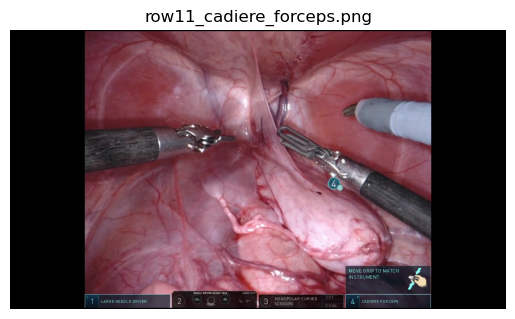

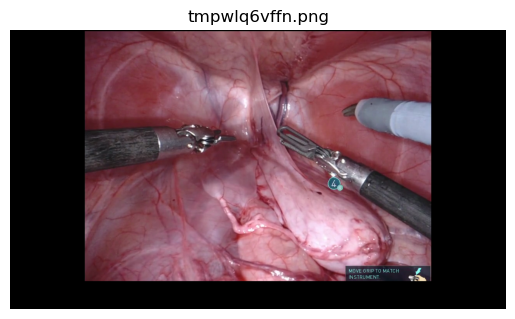

gpt-4o : ```json
{
  "instruments": [
    "Robotic Forceps",
    "Bipolar Forceps",
    "Endoscopic Scissors"
  ]
}
```
GT: cadiere forceps or Large Needle Driver, Monopolar Curved Scissors, Cadiere Forceps


In [39]:
from IPython.display import clear_output
model_id = "gpt-4o"
failed_images = []

for index, row in fetch_generation_data(engine).iterrows():
    uid = str(row["case_id"]) + "_" + str(row["id"])
    question_id = uid
    question_category = "original"
    question = "Identify the surgical tools in the frame"
    actual_answer = row["ground_truth"] + " or " + row["gpt_response"]
    image_link = row["full_file_path"]
    print(question_id, question_category, question, actual_answer, image_link)
    if check_duplicate(engine, uid, str(question_id), question, question_category, model_id, image_link):
        print(f"Duplicate record found for question: {question}. Skipping generation.")
        clear_output(wait=True)
        continue
    display_image(image_link)
    # Coordinates [xmin, ymin, xmax, ymax] for the red box
    mask_rectangle_coords = [0, 705, 1200, 4000]
    mask_fill_color = (0, 0, 0) # Black
    temp_file=mask_bottom_section(image_link, mask_height_percentage=10)
    display_image(temp_file)
    try:
        generated_answer = generate_gpt_response(question, temp_file)

        if generated_answer is None:
            print(f"Image not found: {image_link}")
            failed_images.append(image_link)
            save_failed_images(failed_images)
            continue

        print(f"{model_id} : {generated_answer}")
        print(f"GT: {actual_answer}")
        insert_model_response(engine, uid, question_id, question, question_category, actual_answer, model_id, generated_answer, image_link,"surg_vu")
    except Exception as e:
        print(f"Error generating response for question: {question}. Error: {e}")
        continue
    delete_temp_file(temp_file)
    clear_output(wait=True)


In [ ]:
from IPython.display import clear_output
model_id = "gpt-4o"
failed_images = []

for index, row in fetch_generation_data(engine).iterrows():
    uid = row["id"]
    question_id = row["question_id"]
    question_category = row["question_type"]
    question = row["question"]
    actual_answer = row["ground_truth"]
    image_link = source_folder + row["image"]

    if check_duplicate(engine, uid, str(question_id), question, question_category, model_id, image_link):
        print(f"Duplicate record found for question: {question}. Skipping generation.")
        clear_output(wait=True)
        continue

    try:
        generated_answer = generate_gpt_response(question, image_link)

        if generated_answer is None:
            print(f"Image not found: {image_link}")
            failed_images.append(image_link)
            save_failed_images(failed_images)
            continue

        print(f"{model_id} : {generated_answer}")
        print(f"GT: {actual_answer}")
        insert_model_response(engine, uid, question_id, question, question_category, actual_answer, model_id, generated_answer, image_link)
    except Exception as e:
        print(f"Error generating response for question: {question}. Error: {e}")
        continue

    time.sleep(5)
    print('--------------------------------')
    clear_output(wait=True)

save_failed_images(failed_images)